# Interactive raw voltage viewer

Loads one NWB run **once** into memory as an MNE `Raw` object, with the saturation / variance-outlier / dead flags (from `plot_exclusion_qc.py`) attached as MNE annotations. After that, use MNE's interactive browser to scroll and zoom through the whole run without any reloading.

Kernel: use the `ieeg_ehr_analysis` kernel (Kernel > Change Kernel), which already points at `/home/groups/ckeller1/venvs/ieeg_ehr_analysis`.

In [1]:
%matplotlib widget

In [2]:
import mne
import numpy as np
from pynwb import NWBHDF5IO

from plot_exclusion_qc import find_runs, classify_bins, SAT_THRESHOLD_UV, MAD_SCALE
from raw_voltage_qc import FLATLINE_VAR_THRESHOLD

# MNE's classic matplotlib-based browser (not the Qt one) works with ipympl in Jupyter.
mne.viz.set_browser_backend('matplotlib')

Using matplotlib as 2D backend.


## Load a run

Edit `SUBJECT` / `SESSION` / `RUN` and re-run this cell to switch runs. Everything after this cell (scrolling, zooming, changing the flagging thresholds) does **not** require touching the NWB file again.

In [3]:
SUBJECT = '222'
SESSION = '01'
RUN = 'FA6150R5'          # e.g. 'FA6150R5'; set to None to use the first discovered run
WINDOW_SEC = 2.0          # bin size for exclusion flagging
SAT_THRESHOLD_UV_ = SAT_THRESHOLD_UV   # 2500.0 by default; override here if needed
VAR_STD_THRESH = 5.0      # scaled-MADs from the channel's median bin-variance

# Proof-of-concept: only load a fraction of channels to fit in a smaller Jupyter session.
# Full-channel loads (e.g. 176ch x 7.2M samples float32 ~4.7GB, ~2x that again once MNE
# upcasts to float64 internally) can exceed a default OnDemand session's memory. Set
# CHANNEL_FRACTION=1.0 (and request more RAM in your OnDemand session) once this works.
CHANNEL_FRACTION = 0.10
SEED = 42

nwb_path = find_runs(SUBJECT, SESSION, runs=[RUN] if RUN else None, n_runs=1)[0]
print(f"Loading {nwb_path}")

io = NWBHDF5IO(nwb_path, 'r')
nwb = io.read()
series = nwb.acquisition['ElectricalSeries_sEEG']
assert series.unit == 'volts', f"Unexpected unit: {series.unit}"

sfreq = float(series.rate)
elec_indices = series.electrodes.data[:]
elec_df = nwb.electrodes.to_dataframe().iloc[elec_indices]
all_channel_names = list(elec_df['location'].values)

rng = np.random.default_rng(SEED)
n_pick = max(1, int(round(len(all_channel_names) * CHANNEL_FRACTION)))
idx_sorted = sorted(rng.choice(len(all_channel_names), size=n_pick, replace=False).tolist())
channel_names = [all_channel_names[i] for i in idx_sorted]

print(f"Loading {n_pick}/{len(all_channel_names)} channels "
      f"({CHANNEL_FRACTION:.0%}), {series.data.shape[0]:,} samples each: {channel_names}")
# Fancy-indexing only the selected columns avoids reading the other 90% of channels at all.
data_v = series.data[:, idx_sorted].astype(np.float32) * np.float32(series.conversion)  # (n_samples, n_channels_subset), volts
io.close()
print(f"Loaded. Shape: {data_v.shape}")

Loading /oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/sub-222/ses-01/ieeg/sub-222_ses-01_run-FA6150R5.nwb
Loading 18/176 channels (10%), 7,200,000 samples each: ['LPIN1', 'LPIN2', 'LaIN12', 'LACC2', 'LPLV11', 'LPLV12', 'LPHP5', 'LPHP6', 'LAHP10', 'LAMY8', 'LVOF4', 'LVOF5', 'LVOF6', 'LVOF11', 'RANT3', 'RANT7', 'RAHP3', 'RAHP4']
Loaded. Shape: (7200000, 18)


## Build the MNE Raw object + exclusion annotations

In [12]:
info = mne.create_info(ch_names=channel_names, sfreq=sfreq, ch_types='seeg')
raw = mne.io.RawArray(data_v.T, info, verbose=False)  # MNE wants (n_channels, n_samples), volts
mne.viz.set_browser_backend('matplotlib')

onsets, durations, descriptions, ann_channels = [], [], [], []
sat_v = SAT_THRESHOLD_UV_ * 1e-6

for ch_idx, name in enumerate(channel_names):
    status, spb = classify_bins(data_v[:, ch_idx], sfreq, WINDOW_SEC, sat_v, VAR_STD_THRESH)
    bin_dur = spb / sfreq
    for b, s in enumerate(status):
        if s == 'clean':
            continue
        onsets.append(b * bin_dur)
        durations.append(bin_dur)
        descriptions.append(f'BAD_{s}')   # 'BAD_' prefix -> MNE shows these highlighted by default
        ann_channels.append([name])       # restrict this annotation to just this channel

annotations = mne.Annotations(onset=onsets, duration=durations, description=descriptions,
                               ch_names=ann_channels)
raw.set_annotations(annotations)
print(f"{len(onsets)} flagged bins added as annotations "
      f"(saturated={descriptions.count('BAD_saturated')}, "
      f"variance_outlier={descriptions.count('BAD_variance_outlier')}, "
      f"dead={descriptions.count('BAD_dead')})")

9512 flagged bins added as annotations (saturated=2168, variance_outlier=7344, dead=0)


## Interactive browser

- Scroll/drag or use arrow keys to move through time; `+`/`-` (or the amplitude buttons) to rescale.
- Flagged bins show as colored highlighted spans on their specific channel's row (color per `BAD_*` label, see the legend MNE draws).
- Click a channel name to mark/unmark it bad; click-drag on the trace to add your own annotation.
- Re-running this cell reopens the browser on the *already-loaded* `raw` object — no NWB re-read.
- Change `n_channels` / `duration` / `scalings` below to taste.

In [8]:
# --- Diagnostic: is the ipympl/widget frontend actually working? ---
# If this cell shows a small interactive figure with a blue sine wave and a
# toolbar (pan/zoom/save icons) below it, ipympl is fine and the raw.plot()
# issue is something else (e.g. MNE-specific). If this ALSO shows nothing,
# the problem is the notebook server's widget extension, not MNE/ipympl itself.
import matplotlib.pyplot as plt
import numpy as np
print("matplotlib backend:", plt.get_backend())
fig_test, ax_test = plt.subplots(figsize=(4, 2))
ax_test.plot(np.sin(np.linspace(0, 6.28, 200)))
ax_test.set_title("ipympl diagnostic: do you see a toolbar below this?")
mne.viz.set_browser_backend('matplotlib')
plt.show()

matplotlib backend: Agg


In [7]:
fig = raw.plot(n_channels=min(1), duration=20.0, scalings=dict(seeg=200e-6),
                title=f"sub-{SUBJECT} ses-{SESSION} run-{RUN}", show=True)

TypeError: 'int' object is not iterable

matplotlib backend: widget


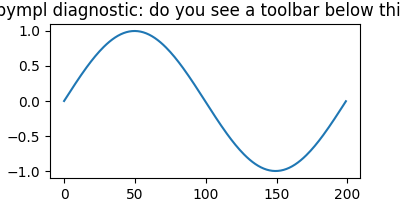

In [13]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
print("matplotlib backend:", plt.get_backend())
fig_test, ax_test = plt.subplots(figsize=(4, 2))
ax_test.plot(np.sin(np.linspace(0, 6.28, 200)))
ax_test.set_title("ipympl diagnostic: do you see a toolbar below this?")
plt.show()

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, FloatSlider

n_channels = 8
window = 3600.0  # 1 hour, in seconds
sfreq = raw.info['sfreq']
total_duration = raw.times[-1]

def plot_window(start=0.0):
    start_samp = int(start * sfreq)
    stop_samp = int((start + window) * sfreq)
    data, times = raw[:n_channels, start_samp:stop_samp]

    spacing = np.max(np.abs(data)) * 1.5 if np.max(np.abs(data)) > 0 else 1.0

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, ch_data in enumerate(data):
        ax.plot(times, ch_data + i * spacing, linewidth=0.5)
    ax.set_yticks([i * spacing for i in range(n_channels)])
    ax.set_yticklabels(raw.ch_names[:n_channels])
    ax.set_xlabel('Time (s)')
    ax.set_title(f"sub-{SUBJECT} ses-{SESSION} run-{RUN} | {start/3600:.2f}h–{(start+window)/3600:.2f}h")
    plt.tight_layout()
    plt.show()

interact(plot_window, start=FloatSlider(
    min=0, max=max(total_duration - window, 0), step=window/4,
    value=0, description='Start (s)', layout={'width': '600px'}
));

interactive(children=(FloatSlider(value=0.0, description='Start (s)', layout=Layout(width='600px'), max=3599.9…